# Phân tích dữ liệu bất động sản từ nhatot

Notebook này thực hiện phân tích dữ liệu bất động sản trong một ngày cụ thể, thống kê theo giá, diện tích, vị trí (Quận, khu vực), số lượt xem, ...

## 1. Import Thư Viện Cần Thiết
Sử dụng pandas, numpy, matplotlib, seaborn để xử lý và trực quan hóa dữ liệu.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Arial'

## 2. Đọc Dữ Liệu Từ File CSV
Đọc file nhatot_full_data.csv bằng pandas, kiểm tra các cột và kiểu dữ liệu.

In [ ]:
file_path = 'nhatot_full_data.csv'
df = pd.read_csv(file_path)
df['Price Value'] = df['Price Value'] / 1e6
df.head()

Số dòng dữ liệu: 486


,ID Ad,Title,Property Type,Price Value,Price String,Price/m2 (trieu),Area (m2),Width,Length,Living Area,...,Seller,Company,Views,Posting Date,Link,[P] Số phòng ngủ,[P] Hướng cửa chính,[P] Loại hình,[P] Chiều ngang,[P] Tình trạng nội thất
0,175644958,"Căn hiếm view cảng – Paris Hoàng Kim, Quận 2",Căn hộ/Chung cư,8850.0,"8,85 tỷ",110.62500,80.0,NaN,NaN,NaN,...,Tài Tăng,True,0,2026-04-24 09:44:41,https://www.nhatot.com/mua-ban-can-ho-chung-cu...,3 PN,Hướng Đông Nam,Chung cư,NaN,NaN
1,175644455,"bán 4Pn- 188m2 , view đầu hồi,sồn, 3bancong , ...",Căn hộ/Chung cư,36000.0,36 tỷ,191.48936,188.0,NaN,NaN,NaN,...,Nguyễn Long,True,0,2026-04-24 09:27:58,https://www.nhatot.com/mua-ban-can-ho-chung-cu...,4 PN,NaN,Chung cư,NaN,NaN
2,175573656,"Bán nhà 146m² đường Nhiêu Tứ, Phú Nhuận – Đất ...",Nhà ở,13500.0,"13,5 tỷ",92.46575,146.0,7.0000,25.0000,NaN,...,nguyễn đức,True,0,2026-04-23 14:10:01,https://www.nhatot.com/mua-ban-nha-dat-quan-ph...,4 PN,NaN,"Nhà ngõ, hẻm",NaN,NaN
3,174222839,[SIÊU PHẨM]–2MT Đường 16m–Dòng Tiền Cao–DƯƠNG ...,Nhà ở,106000.0,106 tỷ,115.91033,914.5,18.2000,42.0000,NaN,...,Mỹ Dung,NaN,0,2026-04-23 14:25:02,https://www.nhatot.com/mua-ban-nha-dat-quan-go...,8 PN,Hướng Bắc,"Nhà mặt phố, mặt tiền",NaN,NaN
4,175182026,"siêu phẩm huỳnh tấn phát chỉ *** 1 căn,giếng t...",Nhà ở,7000.0,7 tỷ,121.73913,57.5,4.0998,14.1998,120.0,...,Nhi Nhi BDS,True,0,2026-04-24 14:07:01,https://www.nhatot.com/mua-ban-nha-dat-quan-7-...,3 PN,NaN,"Nhà ngõ, hẻm",NaN,NaN


In [ ]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID Ad                    486 non-null    int64  
 1   Title                    486 non-null    object 
 2   Property Type            486 non-null    object 
 3   Price Value              486 non-null    float64
 4   Price String             486 non-null    object 
 5   Price/m2 (trieu)         486 non-null    float64
 6   Area (m2)                486 non-null    float64
 7   Width                    290 non-null    float64
 8   Length                   283 non-null    float64
 9   Living Area              160 non-null    float64
 10  Ward                     486 non-null    object 
 11  District                 486 non-null    object 
 12  City                     486 non-null    object 
 13  Street                   486 non-null    object 
 14  Latitude                 4

Index(['ID Ad', 'Title', 'Property Type', 'Price Value', 'Price String',
       'Price/m2 (trieu)', 'Area (m2)', 'Width', 'Length', 'Living Area',
       'Ward', 'District', 'City', 'Street', 'Latitude', 'Longitude', 'Rooms',
       'Toilets', 'Floors', 'House Type', 'Legal Document', 'Furnishing',
       'Phone', 'Seller', 'Company', 'Views', 'Posting Date', 'Link',
       '[P] Số phòng ngủ', '[P] Hướng cửa chính', '[P] Loại hình',
       '[P] Chiều ngang', '[P] Tình trạng nội thất'],
      dtype='object')

## 3. Lọc Dữ Liệu Theo Ngày Cụ Thể
Lọc dữ liệu theo một ngày do người dùng nhập (ví dụ: 2026-04-24), chuyển đổi định dạng ngày nếu cần.

In [111]:
df = df[df['Price Value'].notnull() & (df['Price Value'] > 0)]
df.head()

,ID Ad,Title,Property Type,Price Value,Price String,Price/m2 (trieu),Area (m2),Width,Length,Living Area,...,Seller,Company,Views,Posting Date,Link,[P] Số phòng ngủ,[P] Hướng cửa chính,[P] Loại hình,[P] Chiều ngang,[P] Tình trạng nội thất
0,175644958,"Căn hiếm view cảng – Paris Hoàng Kim, Quận 2",Căn hộ/Chung cư,8850.0,"8,85 tỷ",110.62500,80.0,NaN,NaN,NaN,...,Tài Tăng,True,0,2026-04-24 09:44:41,https://www.nhatot.com/mua-ban-can-ho-chung-cu...,3 PN,Hướng Đông Nam,Chung cư,NaN,NaN
1,175644455,"bán 4Pn- 188m2 , view đầu hồi,sồn, 3bancong , ...",Căn hộ/Chung cư,36000.0,36 tỷ,191.48936,188.0,NaN,NaN,NaN,...,Nguyễn Long,True,0,2026-04-24 09:27:58,https://www.nhatot.com/mua-ban-can-ho-chung-cu...,4 PN,NaN,Chung cư,NaN,NaN
2,175573656,"Bán nhà 146m² đường Nhiêu Tứ, Phú Nhuận – Đất ...",Nhà ở,13500.0,"13,5 tỷ",92.46575,146.0,7.0000,25.0000,NaN,...,nguyễn đức,True,0,2026-04-23 14:10:01,https://www.nhatot.com/mua-ban-nha-dat-quan-ph...,4 PN,NaN,"Nhà ngõ, hẻm",NaN,NaN
3,174222839,[SIÊU PHẨM]–2MT Đường 16m–Dòng Tiền Cao–DƯƠNG ...,Nhà ở,106000.0,106 tỷ,115.91033,914.5,18.2000,42.0000,NaN,...,Mỹ Dung,NaN,0,2026-04-23 14:25:02,https://www.nhatot.com/mua-ban-nha-dat-quan-go...,8 PN,Hướng Bắc,"Nhà mặt phố, mặt tiền",NaN,NaN
4,175182026,"siêu phẩm huỳnh tấn phát chỉ *** 1 căn,giếng t...",Nhà ở,7000.0,7 tỷ,121.73913,57.5,4.0998,14.1998,120.0,...,Nhi Nhi BDS,True,0,2026-04-24 14:07:01,https://www.nhatot.com/mua-ban-nha-dat-quan-7-...,3 PN,NaN,"Nhà ngõ, hẻm",NaN,NaN


In [112]:
df['Date'] = pd.to_datetime(df['Posting Date'])
selected_date = '2026-04-24'
df_day = df[df['Date'].dt.date == pd.to_datetime(selected_date).date()]
df_day.head()

482


,ID Ad,Title,Property Type,Price Value,Price String,Price/m2 (trieu),Area (m2),Width,Length,Living Area,...,Company,Views,Posting Date,Link,[P] Số phòng ngủ,[P] Hướng cửa chính,[P] Loại hình,[P] Chiều ngang,[P] Tình trạng nội thất,Date
0,175644958,"Căn hiếm view cảng – Paris Hoàng Kim, Quận 2",Căn hộ/Chung cư,8850.0,"8,85 tỷ",110.625000,80.0,NaN,NaN,NaN,...,True,0,2026-04-24 09:44:41,https://www.nhatot.com/mua-ban-can-ho-chung-cu...,3 PN,Hướng Đông Nam,Chung cư,NaN,NaN,2026-04-24 09:44:41
1,175644455,"bán 4Pn- 188m2 , view đầu hồi,sồn, 3bancong , ...",Căn hộ/Chung cư,36000.0,36 tỷ,191.489360,188.0,NaN,NaN,NaN,...,True,0,2026-04-24 09:27:58,https://www.nhatot.com/mua-ban-can-ho-chung-cu...,4 PN,NaN,Chung cư,NaN,NaN,2026-04-24 09:27:58
4,175182026,"siêu phẩm huỳnh tấn phát chỉ *** 1 căn,giếng t...",Nhà ở,7000.0,7 tỷ,121.739130,57.5,4.0998,14.1998,120.0,...,True,0,2026-04-24 14:07:01,https://www.nhatot.com/mua-ban-nha-dat-quan-7-...,3 PN,NaN,"Nhà ngõ, hẻm",NaN,NaN,2026-04-24 14:07:01
5,174879709,"Giảm giá 500 triệu bán gấp 90m2, sổ riêng, tại...",Đất,2500.0,"2,5 tỷ",27.777779,90.0,4.1999,25.0000,NaN,...,True,0,2026-04-24 19:38:35,https://www.nhatot.com/mua-ban-dat-thanh-pho-t...,NaN,NaN,Đất thổ cư,Ngang 4.2 m,NaN,2026-04-24 19:38:35
6,175659936,"NHỈNH 4Tỷ - MẶT TIỀN THỤT Lê Quang Định, BÌNH ...",Nhà ở,4000.0,4 tỷ,190.476200,21.0,NaN,NaN,80.0,...,True,0,2026-04-24 19:38:34,https://www.nhatot.com/mua-ban-nha-dat-quan-bi...,2 PN,NaN,"Nhà ngõ, hẻm",NaN,NaN,2026-04-24 19:38:34


## 4. Thống Kê Giá Bất Động Sản (Histogram, Mean, Median, Stddev)
Vẽ biểu đồ histogram cho cột 'Price Value', tính toán mean, median, stddev cho giá bất động sản trong ngày.

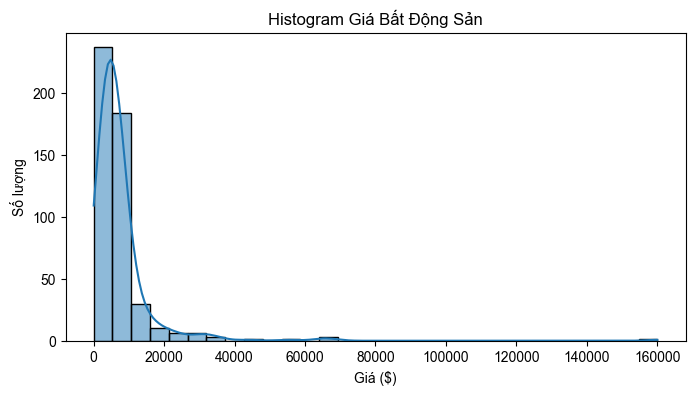

Mean: 7,381.05 | Median: 5,425.00 | Stddev: 10,404.12 | Min: 40.00 | Max: 160,000.00


In [113]:

valid_prices = df_day['Price Value'].dropna()

plt.figure(figsize=(8,4))
sns.histplot(valid_prices, bins=30, kde=True)
plt.title('Histogram Giá Bất Động Sản')
plt.xlabel('Giá ($)')
plt.ylabel('Số lượng')
plt.show()
mean_price = valid_prices.mean()
median_price = valid_prices.median()
std_price = valid_prices.std()
max_price = valid_prices.max()
min_price = valid_prices.min()
print(f"Mean: {mean_price:,.2f} | Median: {median_price:,.2f} | Stddev: {std_price:,.2f} | Min: {min_price:,.2f} | Max: {max_price:,.2f}")


## Phân tích nâng cao dữ liệu bất động sản
Các phân tích: phân phối giá theo loại hình, so sánh giá/diện tích giữa các quận, tương quan giá-diện tích, giá trên mỗi mét vuông, phát hiện outlier.

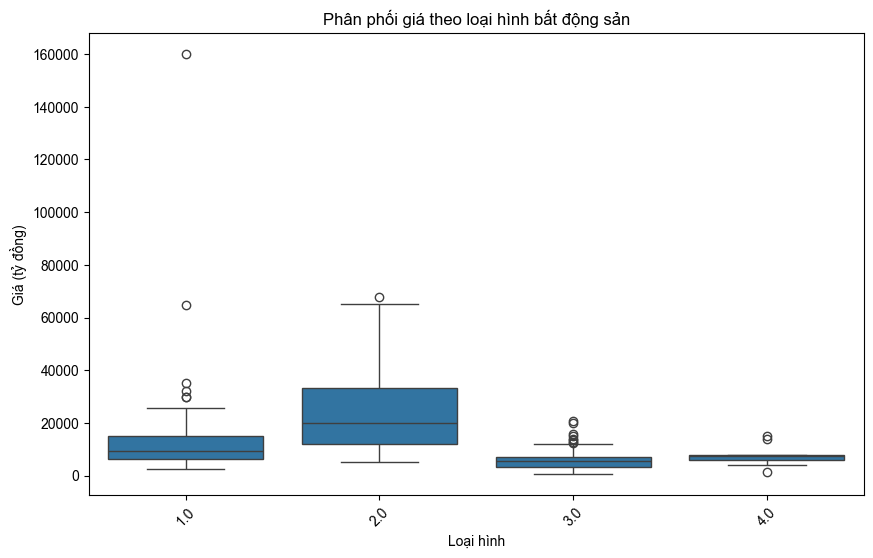

In [114]:
# 1. Phân phối giá theo loại hình bất động sản
plt.figure(figsize=(10,6))
sns.boxplot(data=df_day, x='House Type', y='Price Value')
plt.title('Phân phối giá theo loại hình bất động sản')
plt.xlabel('Loại hình')
plt.ylabel('Giá (tỷ đồng)')
plt.xticks(rotation=45)
plt.show()

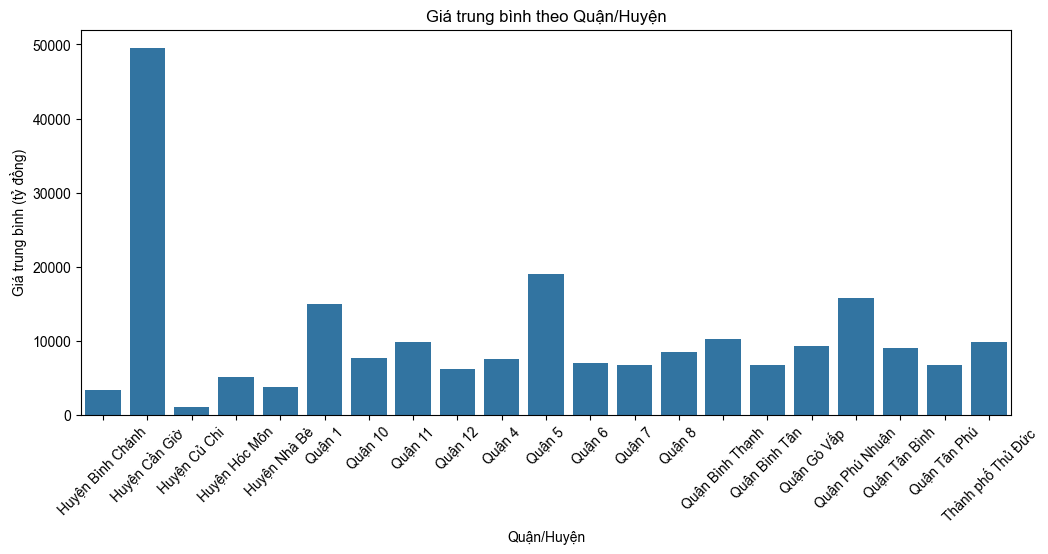

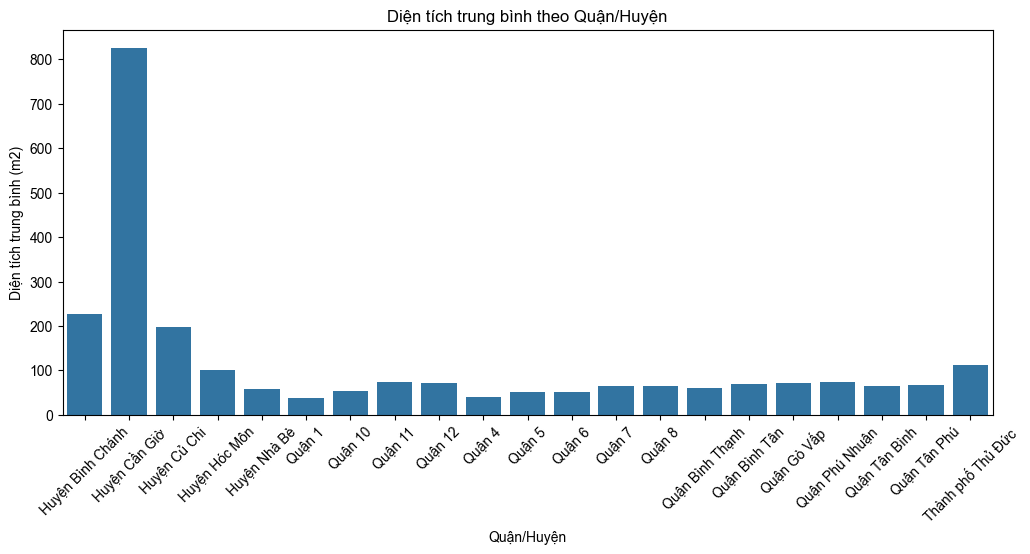

In [115]:
# 2. So sánh giá trung bình, diện tích trung bình giữa các quận/huyện
group = df_day.groupby('District').agg({'Price Value': 'mean', 'Area (m2)': 'mean'}).reset_index()
plt.figure(figsize=(12,5))
sns.barplot(data=group, x='District', y='Price Value')
plt.title('Giá trung bình theo Quận/Huyện')
plt.xlabel('Quận/Huyện')
plt.ylabel('Giá trung bình (tỷ đồng)')
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(12,5))
sns.barplot(data=group, x='District', y='Area (m2)')
plt.title('Diện tích trung bình theo Quận/Huyện')
plt.xlabel('Quận/Huyện')
plt.ylabel('Diện tích trung bình (m2)')
plt.xticks(rotation=45)
plt.show()

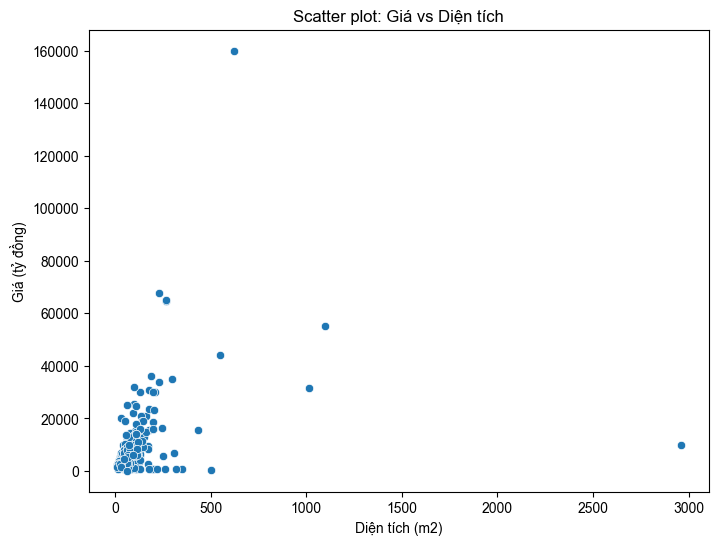

Hệ số tương quan Pearson giữa Giá và Diện tích: 0.34


In [116]:
# 3. Phân tích mối tương quan giữa giá và diện tích
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_day, x='Area (m2)', y='Price Value')
plt.title('Scatter plot: Giá vs Diện tích')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá (tỷ đồng)')
plt.show()
corr = df_day[['Area (m2)', 'Price Value']].corr().iloc[0,1]
print(f'Hệ số tương quan Pearson giữa Giá và Diện tích: {corr:.2f}')

C:\Users\nhanha213\AppData\Local\Temp\ipykernel_21140\3907421870.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['Price_per_m2'] = df_day['Price Value'] / df_day['Area (m2)']


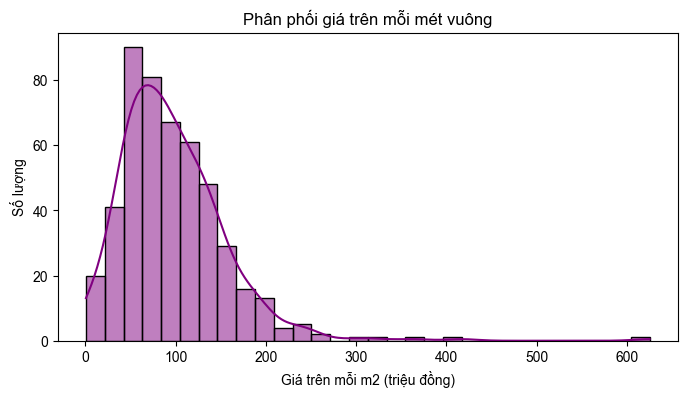

count    482.000000
mean      96.705046
std       60.077256
min        0.615385
25%       55.288194
50%       85.579710
75%      126.350446
max      625.000000
Name: Price_per_m2, dtype: float64


In [117]:
# 4. Phân tích giá trên mỗi mét vuông
df_day['Price_per_m2'] = df_day['Price Value'] / df_day['Area (m2)']
plt.figure(figsize=(8,4))
sns.histplot(df_day['Price_per_m2'].dropna(), bins=30, kde=True, color='purple')
plt.title('Phân phối giá trên mỗi mét vuông')
plt.xlabel('Giá trên mỗi m2 (triệu đồng)')
plt.ylabel('Số lượng')
plt.show()
print(df_day['Price_per_m2'].describe())

In [118]:
# 5. Phát hiện các bất thường (outlier) về giá, diện tích
from scipy import stats

# Outlier giá
z_scores = np.abs(stats.zscore(df_day['Price Value'].dropna()))
outlier_idx = np.where(z_scores > 3)[0]
print(f'Số lượng outlier về giá: {len(outlier_idx)}')
display(df_day.iloc[outlier_idx][['Price Value', 'Area (m2)', 'House Type', 'District']])

# Outlier diện tích
z_scores_area = np.abs(stats.zscore(df_day['Area (m2)'].dropna()))
outlier_idx_area = np.where(z_scores_area > 3)[0]
print(f'Số lượng outlier về diện tích: {len(outlier_idx_area)}')
display(df_day.iloc[outlier_idx_area][['Price Value', 'Area (m2)', 'House Type', 'District']])

Số lượng outlier về giá: 6


,Price Value,Area (m2),House Type,District
14,64800.000000,268.0,1.0,Quận Bình Thạnh
33,67891.234567,229.0,2.0,Quận Gò Vấp
180,44000.000000,550.0,NaN,Huyện Cần Giờ
186,55000.000000,1100.0,NaN,Huyện Cần Giờ
240,65000.000000,268.0,2.0,Thành phố Thủ Đức
408,160000.000000,620.0,1.0,Thành phố Thủ Đức


Số lượng outlier về diện tích: 4


,Price Value,Area (m2),House Type,District
27,31500.0,1013.0,NaN,Thành phố Thủ Đức
160,10000.0,2958.0,NaN,Huyện Bình Chánh
186,55000.0,1100.0,NaN,Huyện Cần Giờ
408,160000.0,620.0,1.0,Thành phố Thủ Đức


## 5. Thống Kê Diện Tích (Histogram, Mean, Median, Stddev)
Vẽ biểu đồ histogram cho cột 'Area (m2)', tính toán mean, median, stddev cho diện tích bất động sản trong ngày.

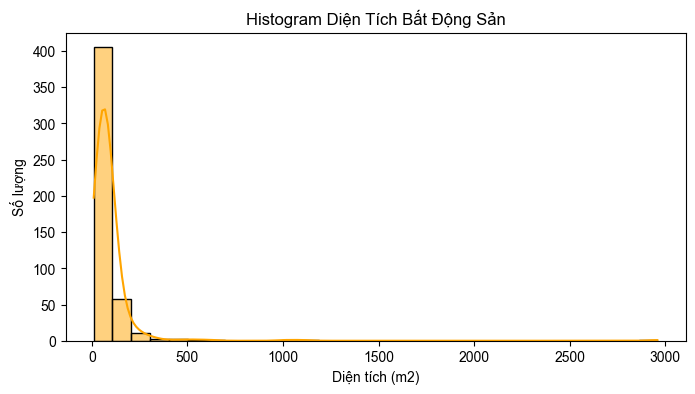

Mean: 88.61 | Median: 64.00 | Stddev: 158.59 | Min: 10.00 | Max: 2958.00


In [119]:
# Thống kê diện tích bất động sản trong ngày
plt.figure(figsize=(8,4))
sns.histplot(df_day['Area (m2)'].dropna(), bins=30, kde=True, color='orange')
plt.title('Histogram Diện Tích Bất Động Sản')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Số lượng')
plt.show()

mean_area = df_day['Area (m2)'].mean()
median_area = df_day['Area (m2)'].median()
std_area = df_day['Area (m2)'].std()
min_area = df_day['Area (m2)'].min()
max_area = df_day['Area (m2)'].max()
print(f"Mean: {mean_area:.2f} | Median: {median_area:.2f} | Stddev: {std_area:.2f} | Min: {min_area:.2f} | Max: {max_area:.2f}")


## 6. Thống Kê Theo Vị Trí (Quận, Khu Vực)
Thống kê số lượng tin đăng, giá trung bình, diện tích trung bình theo từng Quận/District hoặc khu vực.

In [120]:
# Thống kê theo Quận/Khu vực
# Giả sử cột quận là 'District' hoặc 'Quận', cần kiểm tra tên cột thực tế
if 'District' in df_day.columns:
    group_col = 'District'
elif 'Quận' in df_day.columns:
    group_col = 'Quận'
else:
    group_col = None
    print('Không tìm thấy cột Quận/Khu vực.')

if group_col:
    stats_by_district = df_day.groupby(group_col).agg({
        'Price Value': ['count', 'mean'],
        'Area (m2)': 'mean'
    }).rename(columns={'count': 'Số tin', 'mean': 'Trung bình'})
    display(stats_by_district)


Price Value                 Area (m2)
                       Số tin    Trung bình  Trung bình
District                                               
Huyện Bình Chánh           19   3378.184211  226.322200
Huyện Cần Giờ               2  49500.000000  825.000000
Huyện Củ Chi               15   1058.000000  197.613307
Huyện Hóc Môn              29   5050.862069  101.234469
Huyện Nhà Bè               33   3823.242424   58.660603
Quận 1                      2  15000.000000   37.000000
Quận 10                     5   7660.000000   53.000000
Quận 11                     4   9812.500000   73.299925
Quận 12                    74   6144.459460   72.687161
Quận 4                      3   7483.333333   41.133300
Quận 5                      1  19000.000000   52.400000
Quận 6                     10   6963.000000   50.500000
Quận 7                     37   6767.837838   64.043241
Quận 8                     15   8482.000000   65.366667
Quận Bình Thạnh            25  10276.800000   60.555980
Quận Bình Tân              55   6767.181818   69.912713
Quận Gò Vấp                27   9231.342021   72.329630
Quận Phú Nhuận             10  15713.000000   72.900000
Quận Tân Bình              12   8970.833333   65.833333
Quận Tân Phú               35   6670.257143   66.788571
Thành phố Thủ Đức          69   9832.000000  111.818839